# Setup check

Quick sanity check that the deep learning stack works. Runs locally and in Google Colab as-is.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import torch
import torch.nn as nn
import torchvision
import transformers
import datasets

print("python      ", sys.version.split()[0])
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("sklearn     ", sklearn.__version__)
print("torch       ", torch.__version__)
print("torchvision ", torchvision.__version__)
print("transformers", transformers.__version__)
print("datasets    ", datasets.__version__)

python       3.12.13
numpy        2.5.2
pandas       3.0.5
sklearn      1.9.0
torch        2.13.0
torchvision  0.28.0
transformers 5.15.1
datasets     5.0.1


In [2]:
# cuda in Colab, mps on Apple Silicon, cpu otherwise
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("device:", device)

device: mps


In [3]:
# autograd sanity: d(x^2 + 3x)/dx at x=2 should be 7
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3 * x
y.backward()
print("grad:", x.grad.item())
assert x.grad.item() == 7.0

grad: 7.0


loss: 6.4971 -> 0.0093


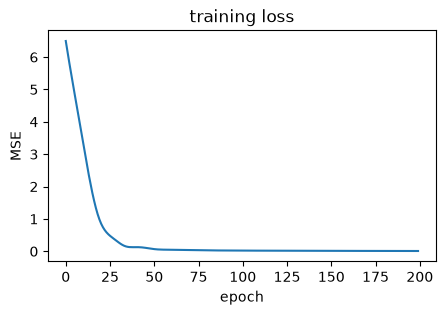

In [4]:
# tiny training loop on the chosen device, loss should drop
torch.manual_seed(42)

X = torch.randn(256, 10, device=device)
true_w = torch.randn(10, 1, device=device)
y = X @ true_w + 0.1 * torch.randn(256, 1, device=device)

model = nn.Sequential(nn.Linear(10, 32), nn.ReLU(), nn.Linear(32, 1)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
criterion = nn.MSELoss()

losses = []
for epoch in range(200):
    optimizer.zero_grad()
    loss = criterion(model(X), y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"loss: {losses[0]:.4f} -> {losses[-1]:.4f}")
assert losses[-1] < losses[0] / 10

plt.figure(figsize=(5, 3))
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("training loss")
plt.show()

In [5]:
# CV side: torchvision transforms on a fake image batch, conv forward pass
from torchvision.transforms import v2

transform = v2.Compose([
    v2.Resize((32, 32)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

imgs = torch.randint(0, 256, (4, 3, 64, 64), dtype=torch.uint8)
batch = transform(imgs).to(device)

conv = nn.Conv2d(3, 16, kernel_size=3, padding=1).to(device)
out = conv(batch)
print("in:", tuple(batch.shape), "out:", tuple(out.shape))

in: (4, 3, 32, 32) out: (4, 16, 32, 32)


In [6]:
# NLP side: tokenizer roundtrip
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
enc = tokenizer("Deep learning for computer vision and NLP.", return_tensors="pt")
print("input_ids:", enc["input_ids"].shape)
print("tokens:", tokenizer.convert_ids_to_tokens(enc["input_ids"][0]))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

input_ids: torch.Size([1, 11])
tokens: ['[CLS]', 'deep', 'learning', 'for', 'computer', 'vision', 'and', 'nl', '##p', '.', '[SEP]']
